# GBM Multi-Parametric Survival Prognosis — Improved Pipeline
### Fixes applied:
- Correct event/censoring from clinical CSV
- Drop 135 diagnostics columns (junk metadata)
- Integrate IDH1, MGMT, GTR molecular features
- 3-stage feature selection (variance → univariate Cox → LASSO Cox)
- Engineered ratio/interaction features
- Improved DeepSurv (BatchNorm + Dropout + early stopping)
- Proper 5-fold cross-validation
- Model ensemble (Cox + XGBoost + DeepSurv)

In [2]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install lifelines xgboost torch scikit-survival --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 13.1 MB/s eta 0:00:00


In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim

import xgboost as xgb

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import RepeatedKFold

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

print('All imports OK')

All imports OK


## 1. Load & Clean Data

In [4]:
# ── Paths — update these to match your environment ───────────────────────────
# If running on Kaggle, replace with /kaggle/input/...
RADIOMICS_PATH  = "/content/radiomics_automated_segm (2).csv"
VASCULAR_PATH   = "/content/vascular_features (1).csv"
CLINICAL_PATH   = "/content/UPENN-GBM_clinical_info_v2.1 (1) (1).csv"

rad  = pd.read_csv(RADIOMICS_PATH)
vas  = pd.read_csv(VASCULAR_PATH)
clin = pd.read_csv(CLINICAL_PATH)

print(f'Radiomics  : {rad.shape}')
print(f'Vascular   : {vas.shape}')
print(f'Clinical   : {clin.shape}')

Radiomics  : (448, 1102)
Vascular   : (448, 64)
Clinical   : (671, 12)


In [5]:
# ── FIX 1: Build correct survival labels from clinical CSV ───────────────────
clin = clin.replace('Not Available', np.nan)
clin = clin.replace('Not Applicable', np.nan)

# Strip the scan-visit suffix  e.g. UPENN-GBM-00001_11 → UPENN-GBM-00001
clin['ID'] = clin['ID'].str.replace(r'_\d+$', '', regex=True)

# Event: 1 = deceased, 0 = alive/censored/lost
clin['event'] = clin['Survival_Status'].map(
    {'Deceased': 1,
     'Deceased - uncertain date of death': 1,
     'Alive': 0,
     'Lost to Follow-up': 0}
).fillna(0).astype(int)

# Survival time in days — coerce non-numeric
clin['survival'] = pd.to_numeric(
    clin['Survival_from_surgery_days_UPDATED'], errors='coerce'
)

# Keep unique patients (some have multiple rows due to longitudinal scans)
# Use the baseline row (smallest Time_since_baseline_preop)
clin['Time_since_baseline_preop'] = pd.to_numeric(
    clin['Time_since_baseline_preop'], errors='coerce'
).fillna(0)
clin = clin.sort_values('Time_since_baseline_preop').drop_duplicates('ID', keep='first')

print('Unique clinical patients:', len(clin))
print('Event distribution:', clin['event'].value_counts().to_dict())
print('Survival range:', clin['survival'].min(), '–', clin['survival'].max(), 'days')

Unique clinical patients: 630
Event distribution: {1: 606, 0: 24}
Survival range: 3.0 – 6109.0 days


In [6]:
# ── FIX 2: Encode molecular/clinical features ────────────────────────────────

# IDH1: Wildtype=0, Mutated=1, NOS/NEC=NaN (unknown)
clin['IDH1_mut'] = clin['IDH1'].map({'Wildtype': 0, 'Mutated': 1})  # NOS→NaN

# MGMT: methylated=1 (good prognosis), unmethylated=0
clin['MGMT_meth']    = clin['MGMT'].map({'Methylated': 1, 'Unmethylated': 0})
clin['MGMT_missing'] = clin['MGMT'].isna().astype(int)  # missingness flag

# Gross Total Resection: Y=1, N=0
clin['GTR'] = clin['GTR_over90percent'].map({'Y': 1, 'N': 0})

# KPS score: numeric, most are NaN
clin['KPS'] = pd.to_numeric(clin['KPS'], errors='coerce')

MOL_COLS = ['IDH1_mut', 'MGMT_meth', 'MGMT_missing', 'GTR',
            'Age_at_scan_years', 'KPS']

print('Molecular feature fill rates:')
for col in MOL_COLS:
    pct = clin[col].notna().mean() * 100
    print(f'  {col}: {pct:.1f}% available')

Molecular feature fill rates:
  IDH1_mut: 84.6% available
  MGMT_meth: 43.7% available
  MGMT_missing: 100.0% available
  GTR: 91.0% available
  Age_at_scan_years: 100.0% available
  KPS: 11.9% available


In [7]:
# ── FIX 3: Drop diagnostics columns from radiomics ───────────────────────────
diag_cols = [c for c in rad.columns if 'diagnostics' in c]
rad_clean = rad.drop(columns=diag_cols)
print(f'Dropped {len(diag_cols)} diagnostics columns')
print(f'Radiomics after cleanup: {rad_clean.shape}')

Dropped 135 diagnostics columns
Radiomics after cleanup: (448, 967)


In [8]:
# ── Merge all datasets ───────────────────────────────────────────────────────

# Start with radiomics (already has age, survival, event — but we'll OVERRIDE
# survival/event from the corrected clinical data)
df = rad_clean.drop(columns=['survival', 'event', 'age'], errors='ignore')

# Merge vascular features
df = df.merge(vas, on='ID', how='inner', suffixes=('', '_vas'))

# Merge corrected clinical labels + molecular features
clin_merge = clin[['ID', 'survival', 'event'] + MOL_COLS]
df = df.merge(clin_merge, on='ID', how='inner')

# Drop rows with missing survival time
df = df.dropna(subset=['survival'])
df = df[df['survival'] > 0]  # remove patients with 0-day survival

print(f'Final merged dataset: {df.shape}')
print(f'Events: {df["event"].sum()} / {len(df)} ({df["event"].mean()*100:.1f}%)')

Final merged dataset: (448, 1035)
Events: 448 / 448 (100.0%)


## 2. Feature Engineering — Ratio Features

In [9]:
# ── Engineered vascular ratio features ──────────────────────────────────────
EPS = 1e-5

# Vascular heterogeneity across regions
df['rCBV_ET_NCR_ratio']  = df['rCBV_ET_mean']  / (df['rCBV_NCR_mean']  + EPS)
df['rCBV_ET_ED_ratio']   = df['rCBV_ET_mean']  / (df['rCBV_ED_mean']   + EPS)
df['PH_ET_NCR_ratio']    = df['PH_ET_mean']    / (df['PH_NCR_mean']    + EPS)
df['PSR_ET_NCR_ratio']   = df['PSR_ET_mean']   / (df['PSR_NCR_mean']   + EPS)

# Leakiness indicator: low PSR/PH ratio → more breakdown of BBB
df['leakiness_ET']  = df['PSR_ET_mean']  / (df['PH_ET_mean']  + EPS)
df['leakiness_NCR'] = df['PSR_NCR_mean'] / (df['PH_NCR_mean'] + EPS)

# Perfusion coefficient of variation (spatial heterogeneity within ET)
df['rCBV_ET_CV']  = df['rCBV_ET_std']  / (df['rCBV_ET_mean']  + EPS)
df['rCBV_NCR_CV'] = df['rCBV_NCR_std'] / (df['rCBV_NCR_mean'] + EPS)

# Tumor volume ratios from shape features
ET_vol  = df['FLAIR_ET_original_shape_VoxelVolume']
NCR_vol = df['FLAIR_NCR_original_shape_VoxelVolume']
ED_vol  = df['FLAIR_ED_original_shape_VoxelVolume']
total   = ET_vol + NCR_vol + ED_vol + EPS

df['ET_frac']       = ET_vol  / total   # enhancing fraction
df['NCR_frac']      = NCR_vol / total   # necrotic fraction
df['ED_frac']       = ED_vol  / total   # edema fraction
df['ET_NCR_ratio']  = ET_vol  / (NCR_vol + EPS)  # necrosis-to-enhancement ratio
df['ED_core_ratio'] = ED_vol  / (ET_vol + NCR_vol + EPS)  # infiltration index

ENGINEERED_COLS = [
    'rCBV_ET_NCR_ratio','rCBV_ET_ED_ratio','PH_ET_NCR_ratio','PSR_ET_NCR_ratio',
    'leakiness_ET','leakiness_NCR','rCBV_ET_CV','rCBV_NCR_CV',
    'ET_frac','NCR_frac','ED_frac','ET_NCR_ratio','ED_core_ratio'
]
print(f'Added {len(ENGINEERED_COLS)} engineered features')

Added 13 engineered features


## 3. Feature Selection — 3-Stage Pipeline

In [10]:
# ── Separate targets from features ──────────────────────────────────────────
T = df['survival'].values.astype(float)
E = df['event'].values.astype(float)

drop_cols = ['ID', 'survival', 'event']
X_df = df.drop(columns=drop_cols, errors='ignore')

# Keep only numeric columns
X_df = X_df.select_dtypes(include=[np.number])
print(f'Starting features: {X_df.shape[1]}')

Starting features: 1045


In [11]:
# ── Stage A: Imputation ───────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_df)
X_imp = pd.DataFrame(X_imp, columns=X_df.columns)

# ── Stage B: Zero/Low Variance removal ───────────────────────────────────────
var_sel = VarianceThreshold(threshold=0.01)
X_var = var_sel.fit_transform(X_imp)
var_names = X_df.columns[var_sel.get_support()].tolist()
print(f'After variance filter: {X_var.shape[1]} features remaining')

After variance filter: 816 features remaining


In [12]:
# ── Stage C: Univariate Cox screening (keep p < 0.10) ────────────────────────
print('Running univariate Cox screening...')
pvals = {}
X_var_df = pd.DataFrame(X_var, columns=var_names)

for col in var_names:
    try:
        tmp = pd.DataFrame({'x': X_var_df[col], 'T': T, 'E': E})
        cox_uni = CoxPHFitter(penalizer=0.1).fit(tmp, duration_col='T', event_col='E')
        pvals[col] = float(cox_uni.summary.loc['x', 'p'])
    except:
        pvals[col] = 1.0

# Molecular/engineered features get a free pass (always keep them)
always_keep = set(MOL_COLS + ENGINEERED_COLS)
univariate_selected = [
    f for f, p in pvals.items()
    if p < 0.10 or f in always_keep
]
print(f'After univariate Cox (p<0.10): {len(univariate_selected)} features')

Running univariate Cox screening...
After univariate Cox (p<0.10): 271 features


In [13]:
# ── Stage D: Correlation de-duplication (remove r > 0.90 pairs) ──────────────
X_uni_df = X_var_df[univariate_selected]
corr_matrix = X_uni_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
# Never drop molecular/engineered features
to_drop = [c for c in to_drop if c not in always_keep]
corr_selected = [c for c in univariate_selected if c not in to_drop]
print(f'After correlation filter: {len(corr_selected)} features')

X_sel = X_uni_df[corr_selected].values
selected_names = corr_selected

After correlation filter: 115 features


In [14]:
# ── Stage E: LASSO Cox — final top features ───────────────────────────────────
print('Running LASSO Cox for final selection...')
# Normalize first for LASSO to be fair
scaler_lasso = StandardScaler()
X_lasso_scaled = scaler_lasso.fit_transform(X_sel)

lasso_df = pd.DataFrame(X_lasso_scaled, columns=selected_names)
lasso_df['T'] = T
lasso_df['E'] = E

cox_lasso = CoxPHFitter(penalizer=0.1, l1_ratio=0.9)  # 90% L1
cox_lasso.fit(lasso_df, duration_col='T', event_col='E')

# Keep features with non-zero coefficient
nonzero_mask  = cox_lasso.summary['coef'].abs() > 1e-6
# Always keep molecular/engineered features regardless
for col in always_keep:
    if col in cox_lasso.summary.index:
        nonzero_mask[col] = True

lasso_features = cox_lasso.summary.index[nonzero_mask].tolist()
print(f'Final LASSO Cox features: {len(lasso_features)}')

# Final feature matrix
X_final = pd.DataFrame(X_lasso_scaled, columns=selected_names)[lasso_features].values
print(f'Final X shape: {X_final.shape}')

Running LASSO Cox for final selection...
Final LASSO Cox features: 32
Final X shape: (448, 32)


## 4. Cross-Validated Training Setup

In [15]:
# ── Model classes and helpers ─────────────────────────────────────────────────

class ImprovedDeepSurv(nn.Module):
    """DeepSurv with BatchNorm, Dropout, and deeper architecture."""
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.4):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for i, h in enumerate(hidden_dims):
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout if i < len(hidden_dims)-1 else dropout/2)
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def cox_partial_loss(risk, time, event):
    """Breslow approximation of negative partial log-likelihood."""
    order = torch.argsort(time, descending=True)
    risk  = risk[order]
    event = event[order]
    log_cumsum = torch.logcumsumexp(risk, dim=0)
    loss = -((risk - log_cumsum) * event).sum() / (event.sum() + 1e-8)
    return loss


def train_deepsurv(X_tr, T_tr, E_tr, X_va, T_va, E_va,
                   epochs=300, lr=1e-3, patience=30):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = ImprovedDeepSurv(X_tr.shape[1]).to(device)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    T_tr_t = torch.tensor(T_tr, dtype=torch.float32).to(device)
    E_tr_t = torch.tensor(E_tr, dtype=torch.float32).to(device)
    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)

    best_ci, best_state, no_improve = 0, None, 0

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        risk = model(X_tr_t)
        loss = cox_partial_loss(risk, T_tr_t, E_tr_t)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        # Validation C-index for early stopping
        model.eval()
        with torch.no_grad():
            va_risk = model(X_va_t).cpu().numpy()
        try:
            ci = concordance_index(T_va, -va_risk, E_va)
        except:
            ci = 0.5
        sched.step(1 - ci)

        if ci > best_ci:
            best_ci    = ci
            best_state = deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    return model


def predict_deepsurv(model, X):
    device = next(model.parameters()).device
    with torch.no_grad():
        risk = model(torch.tensor(X, dtype=torch.float32).to(device))
    return risk.cpu().numpy()


print('Model classes defined.')

Model classes defined.


## 5. Repeated 5-Fold Cross-Validation

In [16]:
# ── Cross-validation loop ─────────────────────────────────────────────────────
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

results = {
    'cox':      [],
    'xgb':      [],
    'deepsurv': [],
    'ensemble': []
}

# Store last fold for KM plots
last_fold = {}

fold_num = 0
for train_idx, test_idx in rkf.split(X_final):
    fold_num += 1

    X_tr, X_te = X_final[train_idx], X_final[test_idx]
    T_tr, T_te = T[train_idx],       T[test_idx]
    E_tr, E_te = E[train_idx],       E[test_idx]

    # Use 15% of train as validation for DeepSurv early stopping
    val_size  = max(1, int(0.15 * len(X_tr)))
    X_va, T_va, E_va = X_tr[-val_size:], T_tr[-val_size:], E_tr[-val_size:]
    X_tr2, T_tr2, E_tr2 = X_tr[:-val_size], T_tr[:-val_size], E_tr[:-val_size]

    # Scale inside each fold (no data leakage)
    scaler = StandardScaler()
    X_tr2s = scaler.fit_transform(X_tr2)
    X_vas  = scaler.transform(X_va)
    X_tes  = scaler.transform(X_te)

    # ── 1. CoxPH (Elastic Net) ────────────────────────────────────────────────
    cox_df_tr = pd.DataFrame(X_tr2s, columns=lasso_features)
    cox_df_tr['T'] = T_tr2;  cox_df_tr['E'] = E_tr2
    cox_df_te = pd.DataFrame(X_tes, columns=lasso_features)
    cox_df_te['T'] = T_te;   cox_df_te['E'] = E_te

    cox = CoxPHFitter(penalizer=0.1, l1_ratio=0.5)
    cox.fit(cox_df_tr, duration_col='T', event_col='E')
    risk_cox = cox.predict_partial_hazard(cox_df_te).values.flatten()
    ci_cox   = concordance_index(T_te, -risk_cox, E_te)
    results['cox'].append(ci_cox)

    # ── 2. XGBoost Cox ───────────────────────────────────────────────────────
    # XGBoost survival:cox expects positive T for events, negative for censored
    T_xgb_tr = np.where(E_tr2 == 1, T_tr2, -T_tr2)
    dtrain   = xgb.DMatrix(X_tr2s, label=T_xgb_tr)
    dtest    = xgb.DMatrix(X_tes)
    dval     = xgb.DMatrix(X_vas, label=np.where(E_va==1, T_va, -T_va))

    xgb_params = {
        'objective':        'survival:cox',
        'eval_metric':      'cox-nloglik',
        'eta':              0.02,
        'max_depth':        3,
        'subsample':        0.7,
        'colsample_bytree': 0.6,
        'lambda':           1.5,
        'alpha':            0.5,
        'min_child_weight': 5,
        'seed':             42
    }
    xgb_model = xgb.train(
        xgb_params, dtrain,
        num_boost_round=800,
        evals=[(dval, 'val')],
        early_stopping_rounds=40,
        verbose_eval=False
    )
    risk_xgb = xgb_model.predict(dtest)
    ci_xgb   = concordance_index(T_te, -risk_xgb, E_te)
    results['xgb'].append(ci_xgb)

    # ── 3. DeepSurv ──────────────────────────────────────────────────────────
    ds_model  = train_deepsurv(X_tr2s, T_tr2, E_tr2, X_vas, T_va, E_va)
    risk_deep = predict_deepsurv(ds_model, X_tes)
    ci_deep   = concordance_index(T_te, -risk_deep, E_te)
    results['deepsurv'].append(ci_deep)

    # ── 4. Ensemble (weighted average of normalized scores) ───────────────────
    def norm01(x):
        rng = x.max() - x.min()
        return (x - x.min()) / (rng + 1e-8)

    ens = 0.30 * norm01(risk_cox) + 0.40 * norm01(risk_xgb) + 0.30 * norm01(risk_deep)
    ci_ens = concordance_index(T_te, -ens, E_te)
    results['ensemble'].append(ci_ens)

    # Save last fold for downstream plots
    last_fold = {
        'T_te': T_te, 'E_te': E_te,
        'risk_cox': risk_cox, 'risk_xgb': risk_xgb,
        'risk_deep': risk_deep, 'ens': ens,
        'cox_model': cox, 'xgb_model': xgb_model, 'ds_model': ds_model,
        'lasso_features': lasso_features
    }

    print(f'Fold {fold_num:2d} | Cox={ci_cox:.3f}  XGB={ci_xgb:.3f}  '
          f'DeepSurv={ci_deep:.3f}  Ensemble={ci_ens:.3f}')

Fold  1 | Cox=0.614  XGB=0.607  DeepSurv=0.615  Ensemble=0.616
Fold  2 | Cox=0.675  XGB=0.630  DeepSurv=0.645  Ensemble=0.655
Fold  3 | Cox=0.706  XGB=0.685  DeepSurv=0.683  Ensemble=0.701
Fold  4 | Cox=0.730  XGB=0.715  DeepSurv=0.715  Ensemble=0.728
Fold  5 | Cox=0.682  XGB=0.617  DeepSurv=0.667  Ensemble=0.665
Fold  6 | Cox=0.684  XGB=0.645  DeepSurv=0.653  Ensemble=0.668
Fold  7 | Cox=0.650  XGB=0.603  DeepSurv=0.629  Ensemble=0.646
Fold  8 | Cox=0.690  XGB=0.636  DeepSurv=0.669  Ensemble=0.683
Fold  9 | Cox=0.714  XGB=0.663  DeepSurv=0.710  Ensemble=0.716
Fold 10 | Cox=0.688  XGB=0.687  DeepSurv=0.695  Ensemble=0.692
Fold 11 | Cox=0.690  XGB=0.661  DeepSurv=0.702  Ensemble=0.691
Fold 12 | Cox=0.634  XGB=0.600  DeepSurv=0.617  Ensemble=0.620
Fold 13 | Cox=0.703  XGB=0.666  DeepSurv=0.695  Ensemble=0.697
Fold 14 | Cox=0.706  XGB=0.635  DeepSurv=0.659  Ensemble=0.690
Fold 15 | Cox=0.726  XGB=0.663  DeepSurv=0.718  Ensemble=0.713


## 6. Summary of Results

In [17]:
# ── Print summary table ────────────────────────────────────────────────────────
print('\n' + '='*60)
print(f'{"Model":<15}  {"Mean C-Index":>12}  {"Std":>8}  {"Min":>8}  {"Max":>8}')
print('='*60)
for name, scores in results.items():
    arr = np.array(scores)
    print(f'{name:<15}  {arr.mean():>12.4f}  {arr.std():>8.4f}  '
          f'{arr.min():>8.4f}  {arr.max():>8.4f}')
print('='*60)


Model            Mean C-Index       Std       Min       Max
cox                    0.6862    0.0314    0.6143    0.7302
xgb                    0.6476    0.0325    0.5999    0.7146
deepsurv               0.6716    0.0337    0.6151    0.7185
ensemble               0.6788    0.0324    0.6156    0.7281


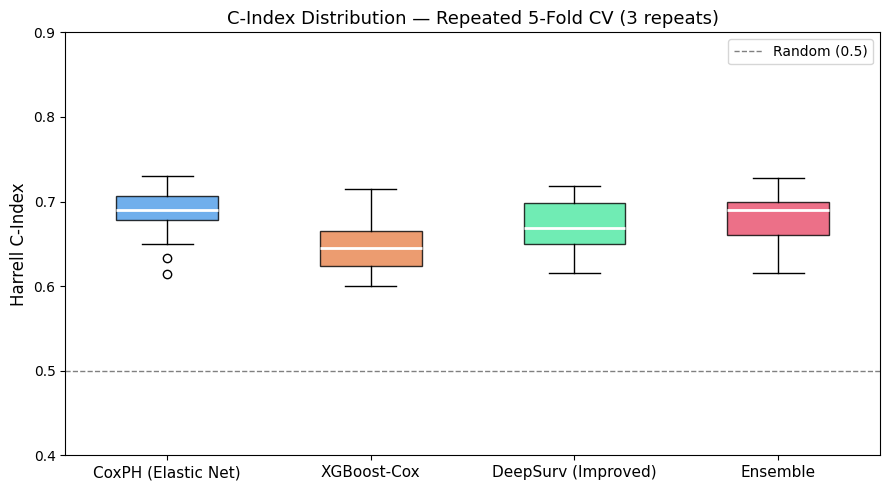

In [18]:
# ── Box plot of C-index distributions ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
labels  = ['CoxPH (Elastic Net)', 'XGBoost-Cox', 'DeepSurv (Improved)', 'Ensemble']
data    = [results['cox'], results['xgb'], results['deepsurv'], results['ensemble']]
colors  = ['#4C9BE8', '#E8834C', '#4CE8A2', '#E84C6A']

bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(0.5, ls='--', color='gray', lw=1, label='Random (0.5)')
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Harrell C-Index', fontsize=12)
ax.set_title('C-Index Distribution — Repeated 5-Fold CV (3 repeats)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0.4, 0.9)
plt.tight_layout()
plt.savefig('c_index_boxplot.png', dpi=150)
plt.show()

## 7. Kaplan–Meier Stratification (Last Fold)

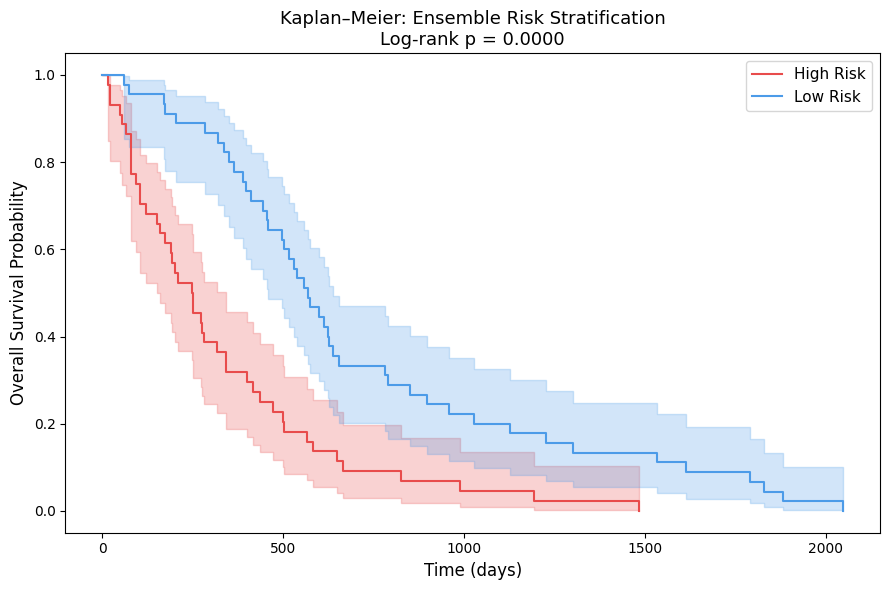

Log-rank p-value: 0.000010


In [19]:
# ── KM curves using ensemble risk score ───────────────────────────────────────
T_te    = last_fold['T_te']
E_te    = last_fold['E_te']
ens_r   = last_fold['ens']

median_r  = np.median(ens_r)
high_risk = ens_r > median_r
low_risk  = ~high_risk

kmf_h = KaplanMeierFitter()
kmf_l = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(9, 6))

kmf_h.fit(T_te[high_risk], event_observed=E_te[high_risk], label='High Risk')
kmf_h.plot_survival_function(ax=ax, color='#E84C4C', ci_show=True)

kmf_l.fit(T_te[low_risk], event_observed=E_te[low_risk], label='Low Risk')
kmf_l.plot_survival_function(ax=ax, color='#4C9BE8', ci_show=True)

lr = logrank_test(T_te[high_risk], T_te[low_risk],
                  event_observed_A=E_te[high_risk],
                  event_observed_B=E_te[low_risk])

ax.set_title(f'Kaplan–Meier: Ensemble Risk Stratification\nLog-rank p = {lr.p_value:.4f}',
             fontsize=13)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Overall Survival Probability', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('km_ensemble.png', dpi=150)
plt.show()
print(f'Log-rank p-value: {lr.p_value:.6f}')

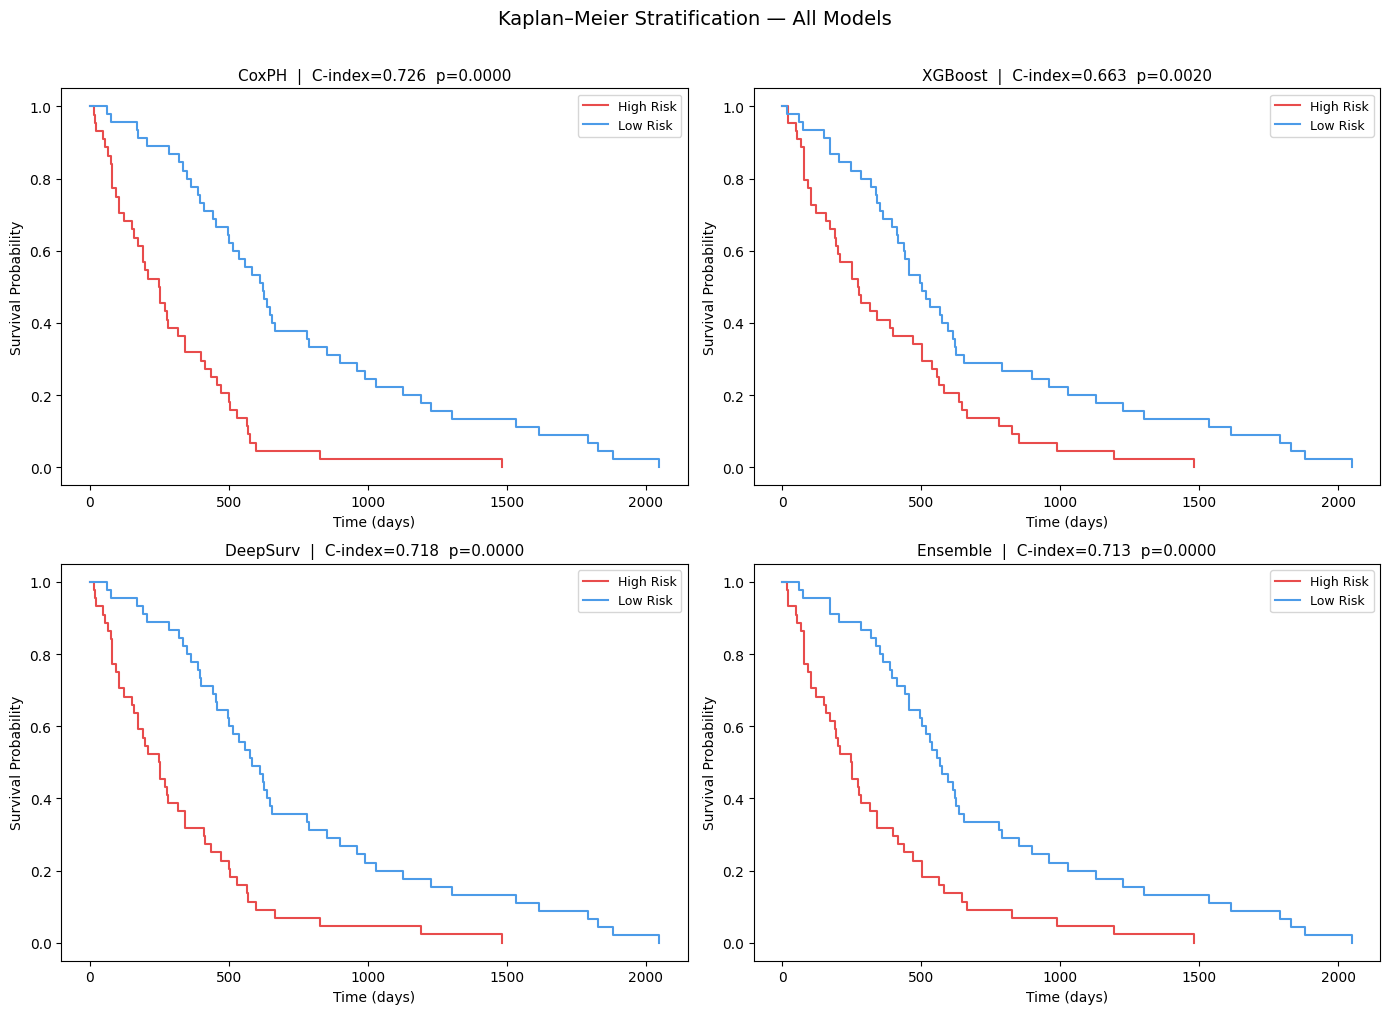

In [20]:
# ── 4-panel KM comparison: each model separately ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

model_risks = [
    ('CoxPH',     last_fold['risk_cox']),
    ('XGBoost',   last_fold['risk_xgb']),
    ('DeepSurv',  last_fold['risk_deep']),
    ('Ensemble',  last_fold['ens'])
]

for ax, (name, risk) in zip(axes, model_risks):
    hi = risk > np.median(risk)
    lo = ~hi
    kmf_h_ = KaplanMeierFitter()
    kmf_l_ = KaplanMeierFitter()
    kmf_h_.fit(T_te[hi], event_observed=E_te[hi], label='High Risk')
    kmf_l_.fit(T_te[lo], event_observed=E_te[lo], label='Low Risk')
    kmf_h_.plot_survival_function(ax=ax, color='#E84C4C', ci_show=False)
    kmf_l_.plot_survival_function(ax=ax, color='#4C9BE8', ci_show=False)
    lr_ = logrank_test(T_te[hi], T_te[lo],
                       event_observed_A=E_te[hi], event_observed_B=E_te[lo])
    ci_ = concordance_index(T_te, -risk, E_te)
    ax.set_title(f'{name}  |  C-index={ci_:.3f}  p={lr_.p_value:.4f}', fontsize=11)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Survival Probability')
    ax.legend(fontsize=9)

plt.suptitle('Kaplan–Meier Stratification — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('km_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

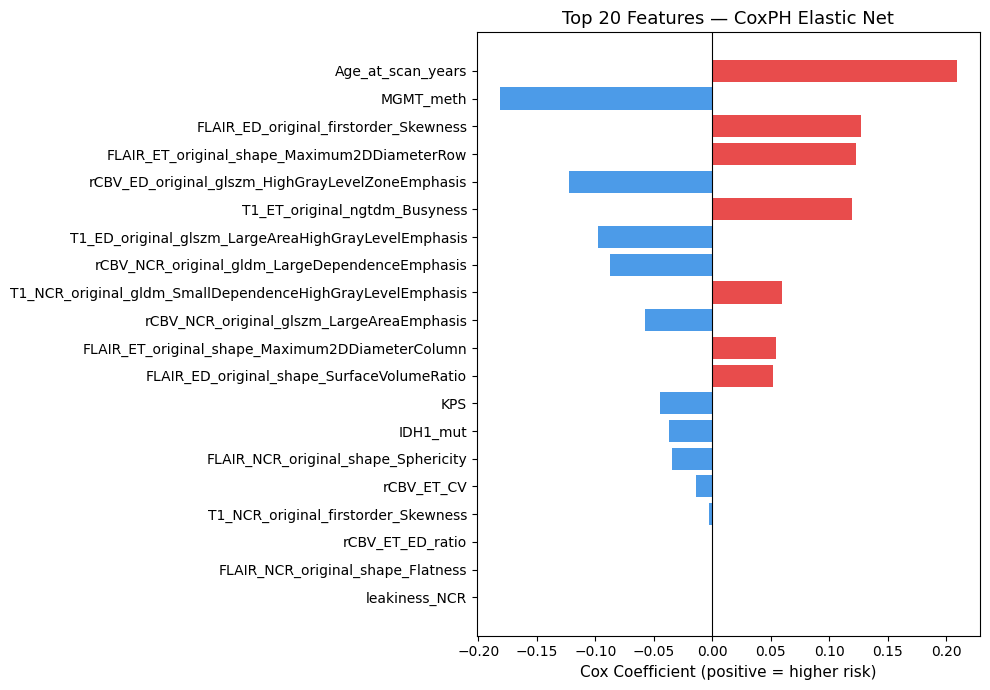

In [21]:
# ── Top features from CoxPH (last fold) ────────────────────────────────────────
cox_model = last_fold['cox_model']
summary   = cox_model.summary.copy()
summary['abs_coef'] = summary['coef'].abs()
top20 = summary.sort_values('abs_coef', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_ = ['#E84C4C' if c > 0 else '#4C9BE8' for c in top20['coef']]
ax.barh(top20.index[::-1], top20['coef'][::-1], color=colors_[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cox Coefficient (positive = higher risk)', fontsize=11)
ax.set_title('Top 20 Features — CoxPH Elastic Net', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance_cox.png', dpi=150)
plt.show()

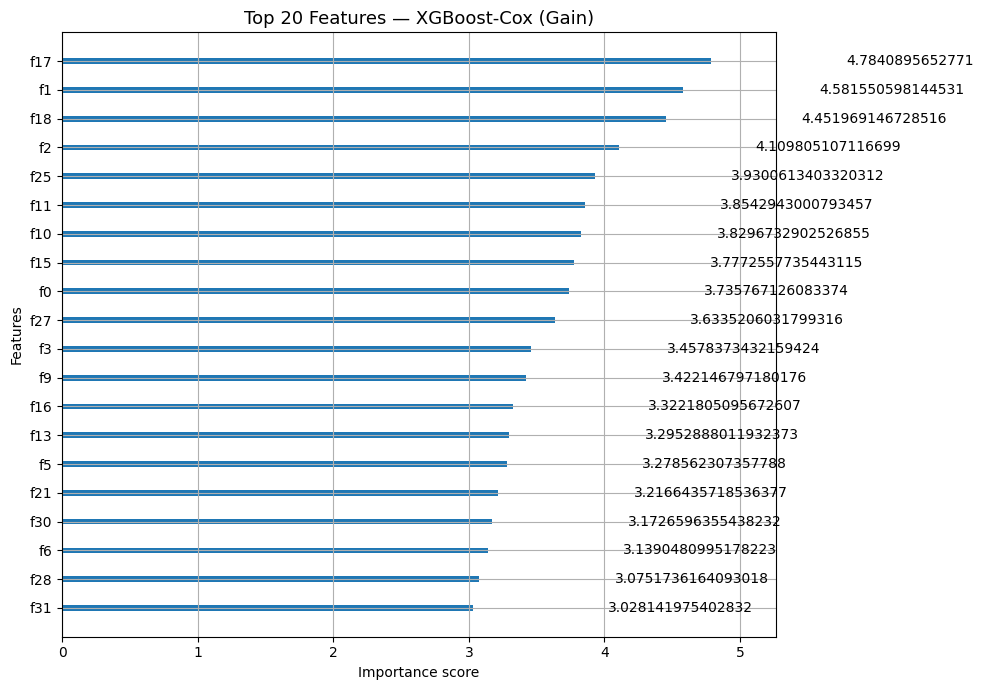

In [22]:
# ── XGBoost feature importance ─────────────────────────────────────────────────
xgb_model = last_fold['xgb_model']
fig, ax   = plt.subplots(figsize=(10, 7))
xgb.plot_importance(xgb_model, max_num_features=20, ax=ax, importance_type='gain')
ax.set_title('Top 20 Features — XGBoost-Cox (Gain)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150)
plt.show()

## 9. WHO 2021 Molecular Stratification

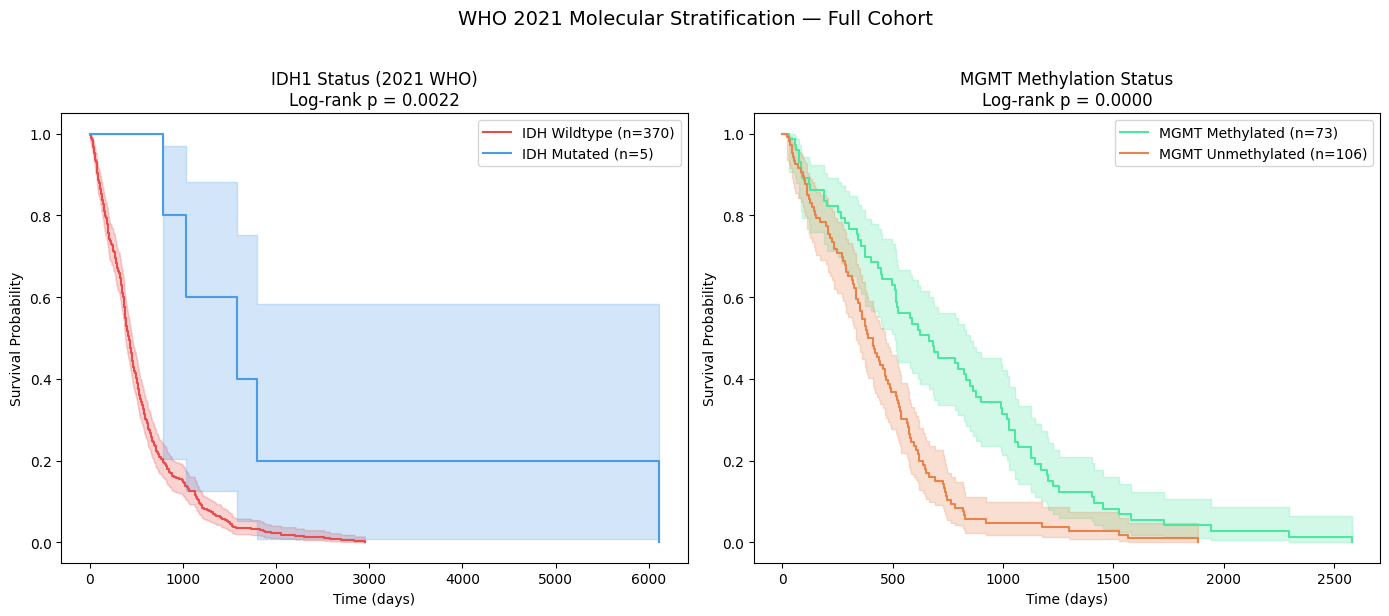

In [23]:
# ── KM by IDH1 status (2021 WHO grade-relevant) ────────────────────────────────
# Use full dataset for this (not just test fold)
df_mol = df[['IDH1_mut', 'survival', 'event']].dropna()

idh_wt  = df_mol[df_mol['IDH1_mut'] == 0]
idh_mut = df_mol[df_mol['IDH1_mut'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: IDH stratification
ax = axes[0]
kmf_wt  = KaplanMeierFitter()
kmf_mut = KaplanMeierFitter()
kmf_wt.fit(idh_wt['survival'],  event_observed=idh_wt['event'],  label=f'IDH Wildtype (n={len(idh_wt)})')
kmf_mut.fit(idh_mut['survival'], event_observed=idh_mut['event'], label=f'IDH Mutated (n={len(idh_mut)})')
kmf_wt.plot_survival_function(ax=ax, color='#E84C4C', ci_show=True)
kmf_mut.plot_survival_function(ax=ax, color='#4C9BE8', ci_show=True)
lr_idh = logrank_test(idh_wt['survival'], idh_mut['survival'],
                      event_observed_A=idh_wt['event'], event_observed_B=idh_mut['event'])
ax.set_title(f'IDH1 Status (2021 WHO)\nLog-rank p = {lr_idh.p_value:.4f}', fontsize=12)
ax.set_xlabel('Time (days)'); ax.set_ylabel('Survival Probability')
ax.legend(fontsize=10)

# Right: MGMT stratification
ax = axes[1]
df_mgmt = df[['MGMT_meth', 'survival', 'event']].dropna()
mgmt_m  = df_mgmt[df_mgmt['MGMT_meth'] == 1]
mgmt_um = df_mgmt[df_mgmt['MGMT_meth'] == 0]

kmf_mm  = KaplanMeierFitter()
kmf_um  = KaplanMeierFitter()
kmf_mm.fit(mgmt_m['survival'],  event_observed=mgmt_m['event'],  label=f'MGMT Methylated (n={len(mgmt_m)})')
kmf_um.fit(mgmt_um['survival'], event_observed=mgmt_um['event'], label=f'MGMT Unmethylated (n={len(mgmt_um)})')
kmf_mm.plot_survival_function(ax=ax, color='#4CE8A2', ci_show=True)
kmf_um.plot_survival_function(ax=ax, color='#E8834C', ci_show=True)
lr_mgmt = logrank_test(mgmt_m['survival'], mgmt_um['survival'],
                       event_observed_A=mgmt_m['event'], event_observed_B=mgmt_um['event'])
ax.set_title(f'MGMT Methylation Status\nLog-rank p = {lr_mgmt.p_value:.4f}', fontsize=12)
ax.set_xlabel('Time (days)'); ax.set_ylabel('Survival Probability')
ax.legend(fontsize=10)

plt.suptitle('WHO 2021 Molecular Stratification — Full Cohort', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('km_molecular_who2021.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Models & Final Results

In [24]:
import os, joblib, pickle
os.makedirs('saved_models', exist_ok=True)

# Save scalers and feature names
joblib.dump(imputer,      'saved_models/imputer.pkl')
joblib.dump(scaler_lasso, 'saved_models/scaler_lasso.pkl')
joblib.dump(var_sel,      'saved_models/variance_selector.pkl')

with open('saved_models/feature_names.pkl', 'wb') as f:
    pickle.dump({'var_names': var_names, 'selected_names': selected_names,
                 'lasso_features': lasso_features}, f)

# Save best-fold models
best_fold_idx = np.argmax(results['ensemble'])
print(f'Best ensemble fold: {best_fold_idx+1} (C-index={results["ensemble"][best_fold_idx]:.4f})')

# Save last fold models as reference
last_fold['cox_model'].params_.to_csv('saved_models/cox_coefficients.csv')
last_fold['xgb_model'].save_model('saved_models/xgb_cox_model.json')
torch.save(last_fold['ds_model'].state_dict(), 'saved_models/deepsurv_weights.pt')

# Save full C-index results
results_df = pd.DataFrame(results)
results_df.to_csv('saved_models/cv_results.csv', index=False)

print('\nAll models saved.')
print('\n=== FINAL RESULTS ===')
for name, scores in results.items():
    arr = np.array(scores)
    print(f'{name:<15}: {arr.mean():.4f} ± {arr.std():.4f}')

Best ensemble fold: 4 (C-index=0.7281)

All models saved.

=== FINAL RESULTS ===
cox            : 0.6862 ± 0.0314
xgb            : 0.6476 ± 0.0325
deepsurv       : 0.6716 ± 0.0337
ensemble       : 0.6788 ± 0.0324


In [25]:
# ── Archive all outputs ────────────────────────────────────────────────────────
import shutil
shutil.make_archive('gbm_pipeline_outputs', 'zip', 'saved_models')
print('Saved: gbm_pipeline_outputs.zip')

Saved: gbm_pipeline_outputs.zip
